In [1]:
# 1. 로보플로우 라이브러리 설치 및 준비
import os
import shutil

# =====================================================================
!pip install roboflow

# roboflow에서 파충류들 사진 가져오기
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("s-workspace-q8ipo").project("reptilesdataset-azlq3")
version = project.version(1)
dataset = version.download("folder")

# =====================================================================

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ReptilesDataset-1 in folder:: 100%|██████████| 9760/9760 [00:13<00:00, 733.25it/s]


In [ ]:
# 전처리 - Roboflow에서 가져온 Data를 내가 사용하는 class로만 압축하기
dataset_path = '/content/ReptilesDataset-1'
popular_classes = [ # 인기 파충류(내가 사용하려는) 종만 필터링
    'Leopard Gecko',
    'African Fat-tail Gecko',
    'Crested Gecko',
    'Central bearded dragon',
    'Common Bluetongue',
    'Common Green Iguana',
    'Argentine black and white Tegu',
    'Ball python',
    'Boa constrictor',
    'Corn snake',
    'Milk snake',
    'Western Hognose Snake',
    'Red-eared slider',
    'Leopard Tortoise',
    'Red-footed tortoise'
]

for split in ['train', 'test', 'valid']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        classes = sorted(os.listdir(split_path))
        print(f"\n[{split}] - {len(classes)}개 클래스") # 전체 클래스 갯수
        for c in classes:
            print(f"  - {c}") # 클래스 이름 각각 뽑기
        break  # train 있으면 거기서 끝

split_path = os.path.join(dataset_path, 'train')
existing_classes = os.listdir(split_path)

# print("✅ 존재하는 클래스:")
# for c in popular_classes:
#     if c in existing_classes:
#         print(f"  ✅ {c}")
#     else:
#         print(f"  ❌ {c} <- 이름 불일치!")

import shutil

# 안 쓰는 클래스(폴더)를 실제로 삭제하는 작업
deleted_count = 0

for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        for folder_name in os.listdir(split_path):
            # 만약 폴더 이름이 내가 지정한 15개 인기 종 리스트에 없다면?
            if folder_name not in popular_classes:
                target_dir = os.path.join(split_path, folder_name)
                shutil.rmtree(target_dir) # 폴더 통째로 삭제
                deleted_count += 1

print(f"🧹 불필요한 클래스 폴더 {deleted_count}개 정제 완료!")
print("📦 현재 [train]에 남은 최종 클래스 개수:", len(os.listdir(os.path.join(dataset_path, 'train'))))
print("🏷️ 최종 라인업:", sorted(os.listdir(os.path.join(dataset_path, 'train'))))


[train] - 45개 클래스
  - African Fat-tail Gecko
  - Argentine black and white Tegu
  - Ball python
  - Black Water Monitor
  - Black-throated monitor
  - Boa constrictor
  - Burmese python
  - California Kingsnake
  - Central bearded dragon
  - Chinese soft-shelled turtle
  - Chinese striped-necked turtle
  - Common Bluetongue
  - Common Golden Tegu
  - Common Green Iguana
  - Common Water Monitor
  - Cooter
  - Corn snake
  - Crested Gecko
  - Cuming's water monitor
  - Diamond python
  - East African sand boa
  - Eastern hognose snake
  - Eastern kingsnake
  - Florida Kingsnake
  - Giant Bluetongue Skink
  - Hainan Cave Gecko
  - Irian Jaya blue-tongued skink
  - Leopard Gecko
  - Leopard Tortoise
  - Mexican black kingsnake
  - Milk snake
  - Mississippi Map Turtle
  - Pink-tongued Skink
  - Red tegu
  - Red-eared slider
  - Red-footed tortoise
  - Reticulated python
  - Rhinoceros iguana
  - Sahel tortoise
  - Savannah Monitor
  - Southern hognose snake
  - Sulfer water monitor lizar

In [ ]:
# 데이터셋 경로 설정
dataset_path = '/content/ReptilesDataset-1'
splits = ['train', 'valid', 'test']

# 각 스플릿별로 돌면서 개수 체크
for split in splits:
    split_path = os.path.join(dataset_path, split)

    print(f"\n==================================================")
    print(f"📊 [{split.upper()}] 세트 품종별 이미지 분포")
    print(f"==================================================")

    if not os.path.exists(split_path):
        print(f"❌ {split} 폴더를 찾을 수 없습니다.")
        continue

    # 알파벳 순서대로 품종 정렬
    classes = sorted(os.listdir(split_path))
    total_images_in_split = 0

    for cls in classes:
        class_path = os.path.join(split_path, cls)

        # 폴더인 경우에만 사진 개수 카운트
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            num_images = len(images)

            # 보기 좋게 정렬해서 출력 (왼쪽 정렬 32칸, 오른쪽 정렬 4칸)
            print(f"  ▪️ {cls:<32} : {num_images:>4} 장")
            total_images_in_split += num_images

    print(f"--------------------------------------------------")
    print(f"📈 {split.upper()} 총합 이미지 수 : {total_images_in_split} 장")


📊 [TRAIN] 세트 품종별 이미지 분포
  ▪️ African Fat-tail Gecko           :  197 장
  ▪️ Argentine black and white Tegu   :   63 장
  ▪️ Ball python                      :  255 장
  ▪️ Boa constrictor                  :   66 장
  ▪️ Central bearded dragon           :  193 장
  ▪️ Common Bluetongue                :  231 장
  ▪️ Common Green Iguana              :  133 장
  ▪️ Corn snake                       :  286 장
  ▪️ Crested Gecko                    :  187 장
  ▪️ Leopard Gecko                    :  239 장
  ▪️ Leopard Tortoise                 :  144 장
  ▪️ Milk snake                       :  411 장
  ▪️ Red-eared slider                 :  205 장
  ▪️ Red-footed tortoise              :  125 장
  ▪️ Western Hognose Snake            :  210 장
--------------------------------------------------
📈 TRAIN 총합 이미지 수 : 2945 장

📊 [VALID] 세트 품종별 이미지 분포
  ▪️ African Fat-tail Gecko           :   55 장
  ▪️ Argentine black and white Tegu   :   28 장
  ▪️ Ball python                      :   88 장
  ▪️ Boa constrictor       

In [ ]:
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torchvision.models as models
# =====================================================================
# 전처리 - 실시간 이미지 증강(Augmentation) 및 데이터 로더 설정
# =====================================================================
# 훈련 데이터용 증강 설정 (클래스당 500장 학습 효과)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 검증 및 테스트용 표준 규격 설정 (증강 안 함)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 데이터셋 객체 생성
train_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, 'train'), transform=train_transform)
valid_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, 'valid'), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(dataset_path, 'test'), transform=val_test_transform)

# 배치 사이즈 32로 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("📈 [Data] 배치 단위 데이터 로더 준비 완료!")

📈 [Data] 배치 단위 데이터 로더 준비 완료!


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

# =====================================================================
# MobileNetV2, ResNet34 다운로드 및 15개 클래스 개조
# =====================================================================

NUM_CLASSES = len(popular_classes)  # 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # cuda 쓸수 있음 쓰고 못쓰면 cpu로
print(f"💻 [Device] 현재 연산 장치: {device}")

# [모델 1] MobileNetV2 개조
mobilenet_model = models.mobilenet_v2(weights='DEFAULT')
in_features_mono = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier[1] = nn.Linear(in_features_mono, NUM_CLASSES) # 출력 노드 15개로 변경
mobilenet_model = mobilenet_model.to(device)

# [모델 2] ResNet34 개조
resnet_model = models.resnet34(weights='DEFAULT')
in_features_res = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features_res, NUM_CLASSES) # 출력 노드 15개로 변경
resnet_model = resnet_model.to(device)

print("\n🤖 MobileNetV2 & ResNet34 사전 학습 모델 개조 및 GPU 탑재 성공!")
print("✨ 이제 이 모델들을 훈련(Train)시킬 모든 무기가 준비되었습니다.")

💻 [Device] 현재 연산 장치: cpu
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 74.2MB/s]



🤖 MobileNetV2 & ResNet34 사전 학습 모델 개조 및 GPU 탑재 성공!
✨ 이제 이 모델들을 훈련(Train)시킬 모든 무기가 준비되었습니다.


In [ ]:
import torch.nn as nn
import torch.optim as optim
import time
from PIL import ImageFile # ◀ 이거 추가

# 깨진 이미지 방어막 켜기
ImageFile.LOAD_TRUNCATED_IMAGES = True # ◀ 이거 추가
# 1. 공통 오차 함수(Loss Function) 정의
# - 아까 말했듯 내부적으로 정수 인덱스와 로짓을 받아 소프트맥스를 계산해 줍니다.
criterion = nn.CrossEntropyLoss()

# 2. 모델을 학습시키고 검증하는 함수 정의
def train_my_model(model, model_name, train_loader, valid_loader, epochs=10, lr=0.001):
    print(f" Let's Go! {model_name} 전이 학습(Fine-tuning)을 시작합니다.")

    # Optimizer 정의: Adam을 사용하고, 기성 가중치가 팍 튀지 않게 학습률(lr)을 조절합니다.
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 시각화 보고서용 기록 장부
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --------------------------------------------------
        # [Train Phase]
        # --------------------------------------------------
        model.train()
        train_loss, train_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # 지난 계산 오차 초기화
            outputs = model(inputs) # 1. 모델이 15개 클래스의 로짓(점수)을 뱉음
            loss = criterion(outputs, labels) # 2. 정답 정수와 비교해 오차 계산
            loss.backward() # 3. 역전파 연산 (오차 역추적)
            optimizer.step() # 4. 가중치 업데이트 (대가리 개조 및 튜닝)

            # 통계 계산
            _, preds = torch.max(outputs, 1) # 가장 높은 로짓 점수를 가진 인덱스 추출
            train_loss += loss.item() * inputs.size(0)
            train_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = train_corrects.double() / len(train_loader.dataset) * 100

        # --------------------------------------------------
        # [Validation Phase]
        # --------------------------------------------------
        model.eval()
        val_loss, val_corrects = 0.0, 0

        with torch.no_grad(): # 시험 볼 때는 성적에 안 반영하니 기울기 계산(공부) 금지
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(valid_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(valid_loader.dataset) * 100

        # 기록 장부에 저장
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        epoch_time = time.time() - epoch_start
        print(f"[Epoch {epoch+1:02d}] Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}% │ Val Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}% │ 소요시간: {epoch_time:.1f}초")

        # 최고 성적 달성 시 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), f'/content/drive/MyDrive/best_{model_name.lower()}.pth')

    total_time = time.time() - start_time
    print(f"\n🎉 {model_name} 학습 완료! 최고 검증 정확도(Best Val Acc): {best_val_acc:.2f}% (총 소요시간: {total_time/60:.1f}분)")
    return history

print("⚙️ 만능 학습 함수(train_my_model) 선언 완료!")

⚙️ 만능 학습 함수(train_my_model) 선언 완료!


In [ ]:
# mobilenet
mobilenet_history = train_my_model(
    model=mobilenet_model,
    model_name="MobileNetV2",
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=20,
    lr=0.0005 # 러닝 레이트 0.0005
)

 Let's Go! MobileNetV2 전이 학습(Fine-tuning)을 시작합니다.
[Epoch 01] Train Loss: 0.3203 | Acc: 89.95% │ Val Loss: 0.4732 | Acc: 86.22% │ 소요시간: 580.8초
[Epoch 02] Train Loss: 0.2735 | Acc: 91.31% │ Val Loss: 0.4165 | Acc: 88.29% │ 소요시간: 564.0초
[Epoch 03] Train Loss: 0.2239 | Acc: 93.45% │ Val Loss: 0.4047 | Acc: 87.49% │ 소요시간: 576.9초
[Epoch 04] Train Loss: 0.2077 | Acc: 93.07% │ Val Loss: 0.3857 | Acc: 89.09% │ 소요시간: 559.7초
[Epoch 05] Train Loss: 0.1647 | Acc: 94.74% │ Val Loss: 0.3793 | Acc: 88.75% │ 소요시간: 598.2초
[Epoch 06] Train Loss: 0.1687 | Acc: 94.47% │ Val Loss: 0.3899 | Acc: 89.55% │ 소요시간: 589.5초
[Epoch 07] Train Loss: 0.1199 | Acc: 96.03% │ Val Loss: 0.4360 | Acc: 89.21% │ 소요시간: 592.6초
[Epoch 08] Train Loss: 0.1321 | Acc: 95.96% │ Val Loss: 0.4146 | Acc: 88.63% │ 소요시간: 599.7초
[Epoch 09] Train Loss: 0.1257 | Acc: 95.99% │ Val Loss: 0.4492 | Acc: 87.72% │ 소요시간: 602.0초
[Epoch 10] Train Loss: 0.1189 | Acc: 96.10% │ Val Loss: 0.3757 | Acc: 89.78% │ 소요시간: 606.5초
[Epoch 11] Train Loss: 0.1181 

In [ ]:
# resnet
resnet_history = train_my_model(
    model=resnet_model,
    model_name="ResNet34",
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=20,
    lr=0.0005 # 러닝 레이트 0.0005
)

 Let's Go! ResNet34 전이 학습(Fine-tuning)을 시작합니다.
[Epoch 01] Train Loss: 1.3082 | Acc: 59.22% │ Val Loss: 1.1926 | Acc: 64.75% │ 소요시간: 1562.6초
[Epoch 02] Train Loss: 0.9177 | Acc: 70.56% │ Val Loss: 1.7752 | Acc: 55.45% │ 소요시간: 1539.4초
[Epoch 03] Train Loss: 0.7610 | Acc: 76.10% │ Val Loss: 1.0130 | Acc: 69.23% │ 소요시간: 1546.2초
[Epoch 04] Train Loss: 0.6705 | Acc: 78.85% │ Val Loss: 1.0064 | Acc: 70.95% │ 소요시간: 1553.4초
[Epoch 05] Train Loss: 0.5463 | Acc: 82.48% │ Val Loss: 0.7669 | Acc: 77.73% │ 소요시간: 1566.0초
[Epoch 06] Train Loss: 0.4675 | Acc: 85.23% │ Val Loss: 1.3534 | Acc: 65.10% │ 소요시간: 1541.8초
[Epoch 07] Train Loss: 0.5252 | Acc: 84.14% │ Val Loss: 1.4772 | Acc: 64.52% │ 소요시간: 1533.8초
[Epoch 08] Train Loss: 0.4191 | Acc: 86.79% │ Val Loss: 0.9154 | Acc: 75.77% │ 소요시간: 1553.7초
[Epoch 09] Train Loss: 0.3651 | Acc: 88.76% │ Val Loss: 0.7820 | Acc: 78.19% │ 소요시간: 1542.5초
[Epoch 10] Train Loss: 0.3437 | Acc: 88.62% │ Val Loss: 0.6730 | Acc: 80.25% │ 소요시간: 1546.7초
[Epoch 11] Train Loss: 

In [ ]:
import os
# 구글 드라이브 내 드라이브에 파일이 잘 있는지 확인
drive_path = '/content/drive/MyDrive'
if os.path.exists(drive_path):
    files = os.listdir(drive_path)
    # 이름에 'resnet'이 들어간 파일이 있는지 필터링
    resnet_files = [f for f in files if 'resnet' in f.lower()]
    print("구글 드라이브 내 레즈넷 가중치 파일 확인:", resnet_files)
else:
    print("구글 드라이브 마운트가 해제되어 있습니다. 왼쪽 폴더 창에서 삼각형 모양 드라이브 아이콘을 다시 눌러주세요!")

📂 구글 드라이브 내 레즈넷 가중치 파일 확인: ['best_resnet34.pth']


🎯 테스트용 데이터 및 모델 로드 성공! 채점을 시작합니다.

🏆 ResNet34 최종 테스트 정확도: 83.75%


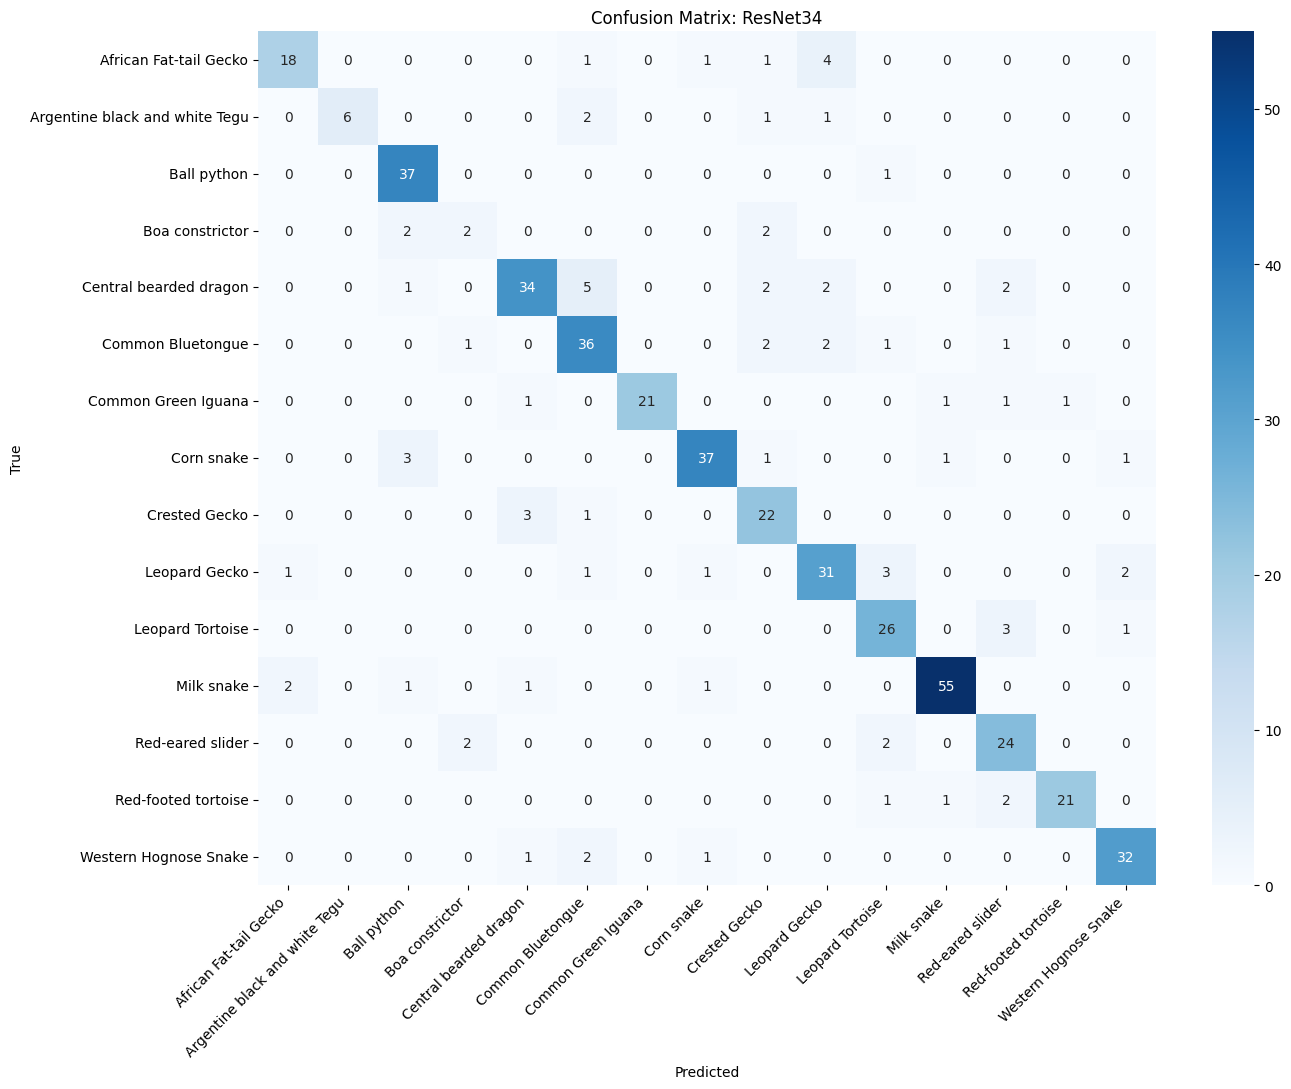

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torchvision.models as models
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 환경 기본 설정 (기존 변수 재선언)
dataset_path = '/content/ReptilesDataset-1'
NUM_CLASSES = 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 테스트 데이터 규격 및 DataLoader 재선언 (NameError 해결 구간)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, 'test'), transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# 3. ResNet34 모델 뼈대 다시 만들고 구글 드라이브 가중치 로드
resnet_model = models.resnet34(weights=None) # 기성 가중치는 내 파일로 덮어쓸 거라 None 처리
in_features_res = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features_res, NUM_CLASSES)

# 내 구글 드라이브에 저장된 최고 성적 파일 주입
resnet_model.load_state_dict(torch.load('/content/drive/MyDrive/best_resnet34.pth', map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

print("🎯 테스트용 데이터 및 모델 로드 성공! 채점을 시작합니다.\n")

# 4. 테스트 데이터로 최종 채점
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. 결과 분석 및 정확도 출력
accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
print(f"==================================================")
print(f"🏆 ResNet34 최종 테스트 정확도: {accuracy:.2f}%")
print(f"==================================================")

# 6. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: ResNet34')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

🎯 MobileNetV2 가중치 파일 로드 성공!
🏁 테스트용 데이터 및 모델 로드 완료! 채점을 시작합니다.

🏆 MobileNetV2 최종 테스트 정확도: 90.83%


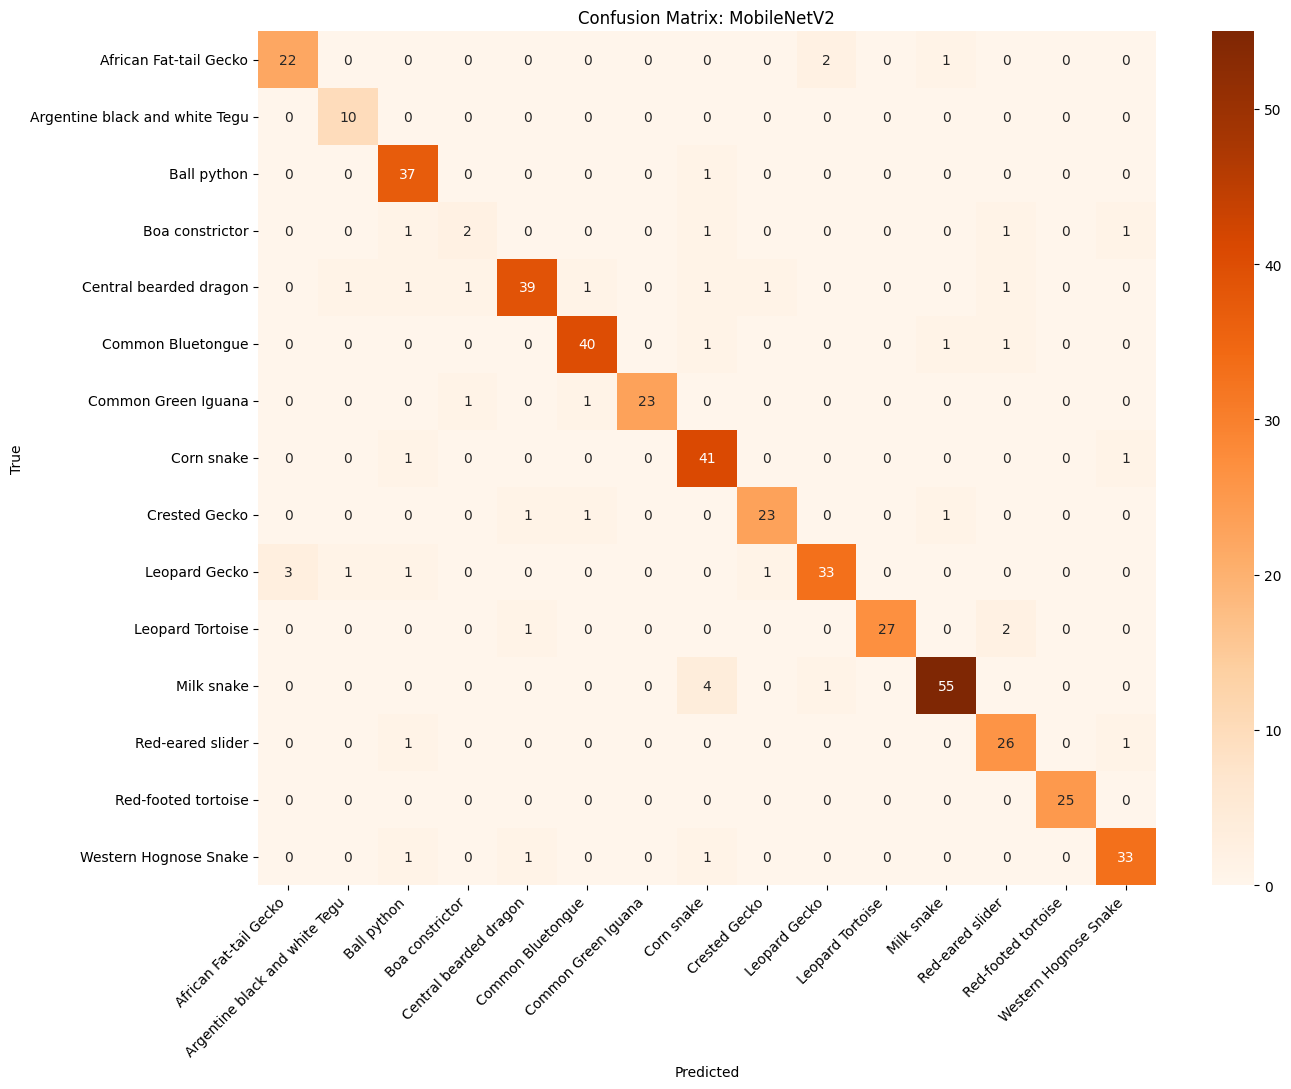

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torchvision.models as models
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 환경 기본 설정
dataset_path = '/content/ReptilesDataset-1'
NUM_CLASSES = 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 테스트 데이터 규격 및 DataLoader 선언
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, 'test'), transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# 3. MobileNetV2 모델 뼈대 다시 만들고 구글 드라이브 가중치 로드
mobilenet_model = models.mobilenet_v2(weights=None) # 기성 가중치는 내 파일로 덮어쓸 거라 None 처리
in_features_mono = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier[1] = nn.Linear(in_features_mono, NUM_CLASSES) # 출력 노드 15개 개조

# 내 구글 드라이브에 저장된 최고 성적 파일 주입 (파일명 대소문자 주의)
# 만약 파일명이 다르면 'best_mobilenetv2.pth' 부분을 실제 저장된 파일명으로 수정해주세요!
model_path = '/content/drive/MyDrive/best_mobilenetv2.pth'

if os.path.exists(model_path):
    mobilenet_model.load_state_dict(torch.load(model_path, map_location=device))
    print("🎯 MobileNetV2 가중치 파일 로드 성공!")
else:
    # 혹시 소문자로 저장 안 되었을 경우를 대비한 가드 코드
    alternative_path = '/content/drive/MyDrive/best_mobilenetv2.pth'
    mobilenet_model.load_state_dict(torch.load(alternative_path, map_location=device))
    print("🎯 MobileNetV2 가중치 파일 로드 성공! (대체 경로)")

mobilenet_model = mobilenet_model.to(device)
mobilenet_model.eval()

print("🏁 테스트용 데이터 및 모델 로드 완료! 채점을 시작합니다.\n")

# 4. 테스트 데이터로 최종 채점
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = mobilenet_model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. 결과 분석 및 정확도 출력
accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
print(f"==================================================")
print(f"🏆 MobileNetV2 최종 테스트 정확도: {accuracy:.2f}%")
print(f"==================================================")

# 6. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # 레즈넷(Blues)과 비교하기 쉽게 주황색 톤으로 변경
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: MobileNetV2')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import coremltools as ct

# =====================================================================
# 1. 환경 기본 설정 (기존과 동일)
# =====================================================================
dataset_path = '/content/ReptilesDataset-1'
NUM_CLASSES  = 15
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, 'train'), transform=val_test_transform)
class_labels = train_dataset.classes
print("📋 클래스 순서:", class_labels)

# =====================================================================
# 2. [핵심] CoreML 완벽 변환용 정규화 래퍼(Wrapper) 클래스
# =====================================================================
class CoreMLWrapper(nn.Module):
    def __init__(self, core_model):
        super().__init__()
        self.core_model = core_model
        # 파이토치의 mean과 std를 모델 내부(버퍼)에 심어버립니다.
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        # 들어오는 x (0~1 스케일)를 내부에서 완벽하게 정규화
        x = (x - self.mean) / self.std
        return self.core_model(x)

# 더미 입력 텐서 (변환 시 모델에 한 번 흘려보낼 가짜 이미지)
dummy_input = torch.randn(1, 3, 224, 224)

def convert_to_coreml(model, model_name):
    print(f"\n🔄 {model_name} CoreML 변환 중...")

    # 1. 모델을 래퍼 클래스로 감싸서 CPU 모드로 준비
    wrapped_model = CoreMLWrapper(model).eval().cpu()

    # 2. PyTorch 모델의 실행 경로를 추적(Trace)
    traced = torch.jit.trace(wrapped_model, dummy_input)

    # 3. CoreML로 변환
    mlmodel = ct.convert(
        traced,
        inputs=[ct.ImageType(
            name="input_1",
            shape=dummy_input.shape,
            color_layout=ct.colorlayout.RGB,
            scale=1 / 255.0
        )],
        classifier_config=ct.ClassifierConfig(class_labels),
    )

    # 4. 메타데이터(설명) 달아주기
    mlmodel.short_description = f"반려 파충류 15종 분류 - {model_name}"
    mlmodel.author  = "Chan-hwi Kang"
    mlmodel.version = "1.0"

    # 🌟 [수정 완료] .mlmodel 대신 최신 포맷 규격인 .mlpackage로 확장자 변경!
    filename = f"/content/drive/MyDrive/{model_name}.mlpackage"

    mlmodel.save(filename)
    print(f"  ✅ 저장 완료! → {filename}")

# =====================================================================
# 3. MobileNetV2 로드 + 변환
# =====================================================================
print("\n📦 MobileNetV2 로드 중...")
mobilenet_model = models.mobilenet_v2(weights=None)
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.last_channel, NUM_CLASSES)
mobilenet_model.load_state_dict(torch.load('/content/drive/MyDrive/best_mobilenetv2.pth', map_location=device))
mobilenet_model = mobilenet_model.to(device)

convert_to_coreml(mobilenet_model, "MobileNetV2")

# =====================================================================
# 4. ResNet34 로드 + 변환
# =====================================================================
print("\n📦 ResNet34 로드 중...")
resnet_model = models.resnet34(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
resnet_model.load_state_dict(torch.load('/content/drive/MyDrive/best_resnet34.pth', map_location=device))
resnet_model = resnet_model.to(device)

convert_to_coreml(resnet_model, "ResNet34")

print("\n🎉 두 모델 변환 완료!")

📋 클래스 순서: ['African Fat-tail Gecko', 'Argentine black and white Tegu', 'Ball python', 'Boa constrictor', 'Central bearded dragon', 'Common Bluetongue', 'Common Green Iguana', 'Corn snake', 'Crested Gecko', 'Leopard Gecko', 'Leopard Tortoise', 'Milk snake', 'Red-eared slider', 'Red-footed tortoise', 'Western Hognose Snake']

📦 MobileNetV2 로드 중...

🔄 MobileNetV2 CoreML 변환 중...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 67.29 passes/s]


  ✅ 저장 완료! → /content/drive/MyDrive/MobileNetV2.mlpackage

📦 ResNet34 로드 중...

🔄 ResNet34 CoreML 변환 중...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 181.00 passes/s]


  ✅ 저장 완료! → /content/drive/MyDrive/ResNet34.mlpackage

🎉 두 모델 변환 완료!
